# 02 · Unsupervised structure: PCA, t-SNE and clustering

Before predicting anything, do the agronomic variables organise the lots into natural groups (by origin, altitude band, processing…) that a classifier could exploit? This notebook applies PCA, t-SNE, k-means, hierarchical clustering and DBSCAN to the six numeric variables (moisture, the two defect counts, altitude, longitude and |latitude|).

There is no train/test boundary to respect here, so missing altitudes and moisture are filled on the whole dataset (`data.impute_for_eda`) — this is the only place where that is acceptable.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from coffee_quality import config as C
from coffee_quality import data, eda, plotting as P

P.set_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
from coffee_quality import unsupervised as U
from scipy.cluster.hierarchy import dendrogram

df = data.impute_for_eda(data.load_clean())
X = U.numeric_matrix(df)
y = df.loc[X.index, C.TARGET]
X.describe().round(2)

,Moisture,Category.One.Defects,Category.Two.Defects,altitude_mean_meters,Longitude,LatitudeAbs
count,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00
mean,0.11,0.43,3.63,1305.71,-48.92,16.70
std,0.02,1.84,5.31,403.86,68.24,10.41
min,0.01,0.00,0.00,200.00,-155.43,0.13
25%,0.11,0.00,0.00,1094.99,-91.64,9.46
50%,0.11,0.00,2.00,1310.64,-75.59,16.12
75%,0.12,0.00,4.00,1600.00,-44.00,21.44
max,0.28,31.00,55.00,3280.00,145.58,39.76


## 1. Principal component analysis

,PC1,PC2,PC3,PC4,PC5,PC6
Moisture,0.123,0.259,-0.515,0.794,-0.147,0.031
Category.One.Defects,0.444,0.343,0.524,0.040,-0.598,0.228
Category.Two.Defects,0.439,0.503,0.174,0.017,0.703,-0.172
altitude_mean_meters,-0.509,0.513,-0.040,-0.117,0.128,0.668
Longitude,-0.195,-0.375,0.594,0.582,0.284,0.224
LatitudeAbs,0.546,-0.398,-0.276,-0.127,0.174,0.649


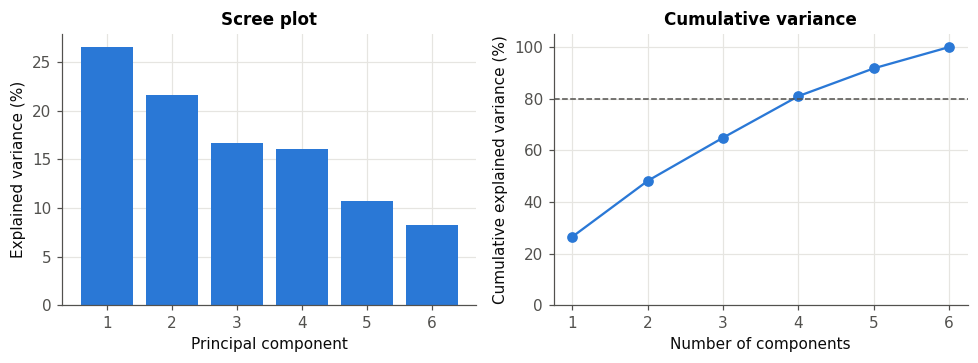

In [2]:
pca, Z, scores, loadings = U.fit_pca(X)
P.plot_pca_variance(pca);
loadings.round(3)

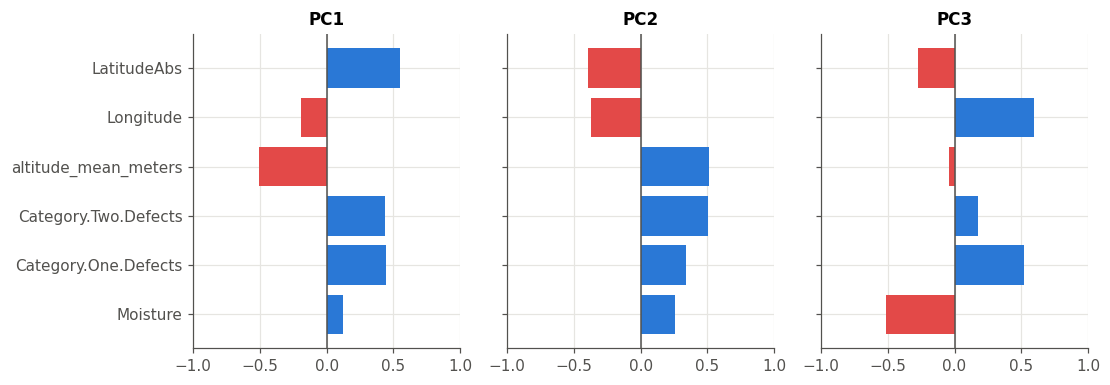

In [3]:
P.plot_pca_loadings(loadings, 3);

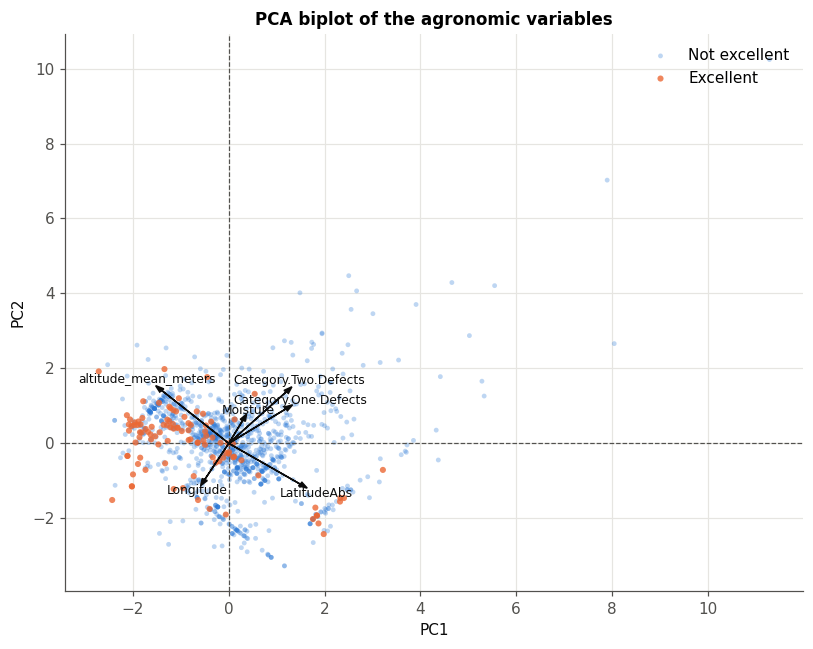

In [4]:
P.plot_pca_biplot(scores, loadings, y);

No dominant direction: the first component explains 27% of the variance and four components are needed to pass 80%. PC1 contrasts *defects and distance from the equator* against *altitude*; PC2 is an *altitude + defects* axis; PC3 is essentially moisture. The excellent lots (orange) drift toward high altitude / low defects but overlap heavily with everything else — exactly what the supervised models will struggle with.

## 2. t-SNE

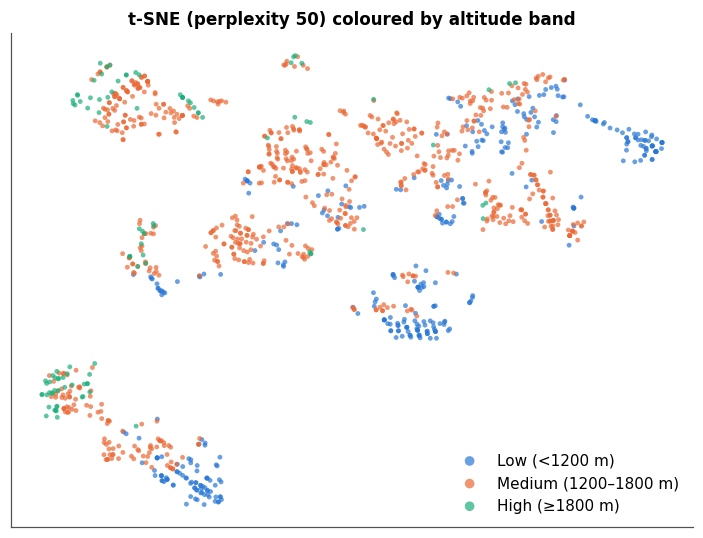

In [5]:
bands, band_names = U.altitude_band(X["altitude_mean_meters"])
emb = U.fit_tsne(Z)
P.plot_embedding(emb, bands, band_names, "t-SNE (perplexity 50) coloured by altitude band");

The embedding is organised by altitude band, not by any hidden grouping: the low/medium/high lots form a gradient rather than islands. Small isolated blobs correspond to lots sharing identical (imputed) region-level altitudes.

## 3. k-means

,standardised variables,first 3 PCs
k,,
2,0.189,0.275
3,0.232,0.300
4,0.244,0.349
5,0.259,0.358
6,0.268,0.349


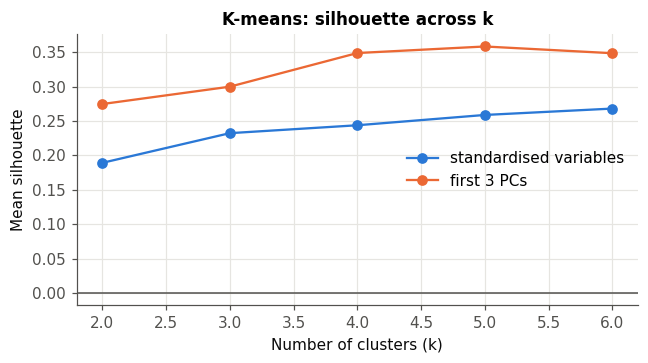

In [6]:
sil = U.kmeans_silhouettes(Z, scores)
P.plot_silhouette_scores(sil);
sil.round(3)

Silhouette scores stay in the 0.2–0.4 range for every *k*, on the standardised variables and on the first three PCs alike: partitions exist, but they are weak and mostly slice the altitude gradient. There is no *k* at which the data "snaps" into well-separated groups.

## 4. Hierarchical clustering

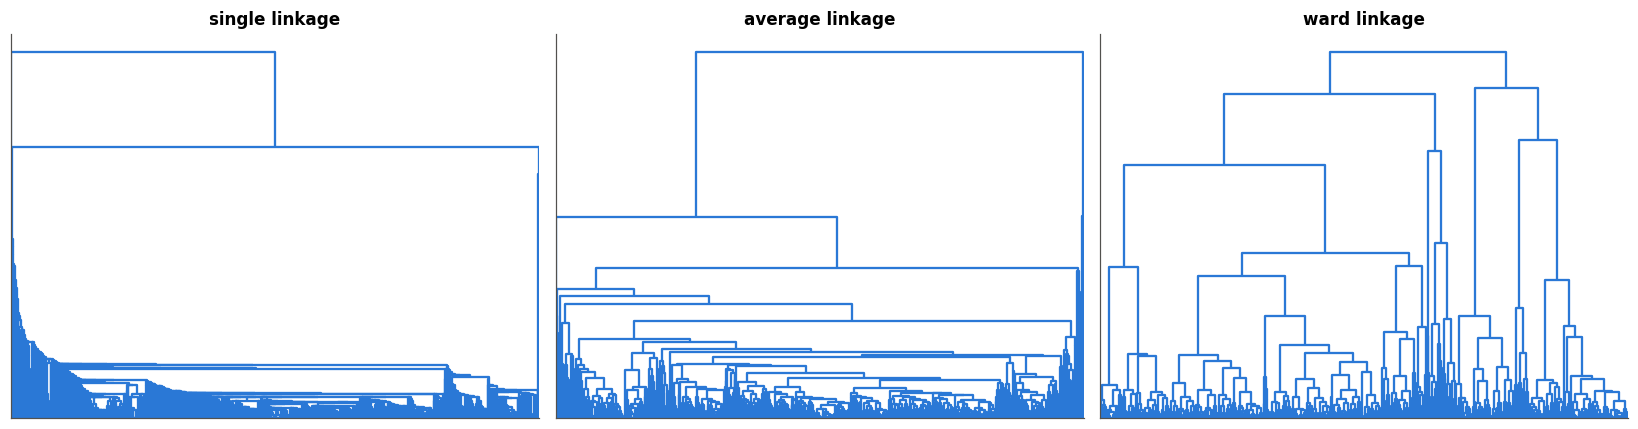

In [7]:
links = U.hierarchical_linkages(Z)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, method in zip(axes, ["single", "average", "ward"]):
    dendrogram(links[method], ax=ax, no_labels=True, color_threshold=0, above_threshold_color=P.SERIES[0])
    ax.set_title(f"{method} linkage")
    ax.set_yticks([])
plt.tight_layout()

Single and average linkage produce the typical "one giant cluster plus outliers" chain of a continuous cloud; Ward linkage forces balanced groups but the merge heights grow smoothly, without the large jump that would signal a natural cut.

## 5. DBSCAN

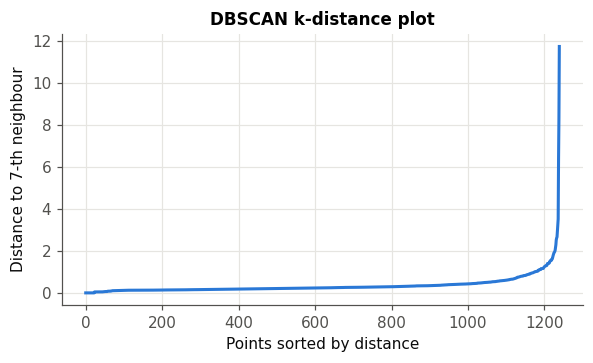

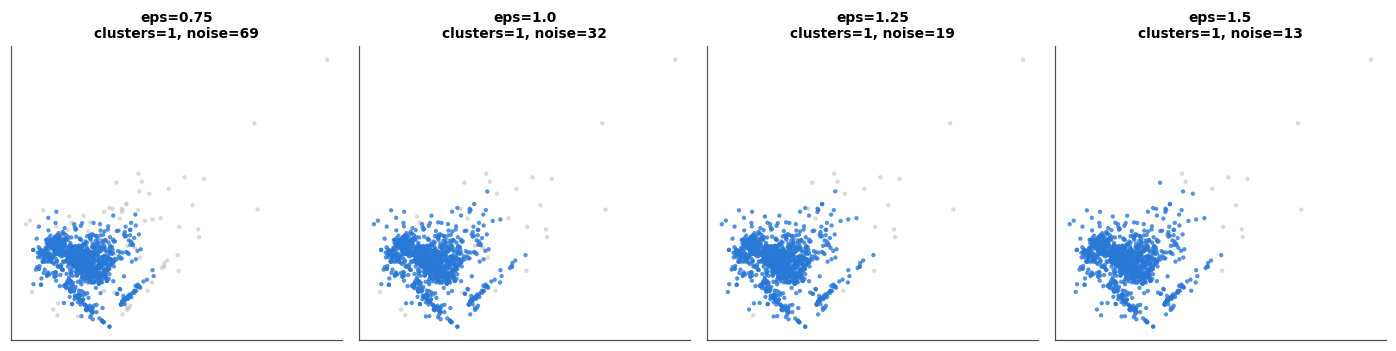

In [8]:
P.plot_k_distance(U.k_distances(scores[:, :3]), 7);
P.plot_dbscan_grid(scores, U.dbscan_sweep(scores[:, :3]));

Whatever the radius, DBSCAN finds **one** dense cluster and labels the remaining points as noise; increasing ε only reabsorbs the noise. Density-based clustering agrees with the other methods.

## Conclusion

The agronomic variables describe a **single continuous population stretched along the altitude axis**, not a set of discrete coffee "types". Clustering cannot serve as a feature or a pre-filter; the classification problem has to be attacked directly, and the class overlap seen in the biplot already warns that it will be hard.